# 03 — The 263-number vector, and the bug that reads it wrong (F1)

## The question, in one sentence

**If you take the first 66 numbers out of every frame's 263-number motion vector and call that
"the skeleton," do you actually get a skeleton?**

The original failed course project did exactly this (`motion[:66]` reshaped to 22 joints x 3
coordinates). This notebook shows, visually, why that produces a broken figure — and proves it
without asking anyone to trust an explanation.

## The intuition, before any numbers

Imagine a form with five sections, filled out one after another on the same sheet of paper, with
no headers printed between them:

```
[ 4 boxes: which way am I turning, how fast, how tall ]
[ 63 boxes: where is every joint, relative to my hips  ]
[ 126 boxes: which way is every joint rotated           ]
[ 66 boxes: how fast is every joint currently moving     ]
[ 4 boxes: are my feet touching the ground               ]
                                                    total: 263 boxes
```

Now imagine someone is told "the joint positions are the first 66 boxes" and they start counting
from box 1 instead of box 5. They read the last 4 boxes of the *first* section (which are
"turning speed, tilt, height" — not a joint at all) as if they were a joint's x/y/z coordinates,
then every joint after that is shifted by 4 boxes, permanently out of step with which section of
the form it is actually reading.

That is the entire bug. `motion[:66]` grabs 4 root-motion numbers plus only 62 of the 63
joint-position numbers, and reshapes the result into what it *assumes* are 22 clean (x, y, z)
triples. Nothing downstream knows the alignment is wrong — it just gets a number and draws a dot
where that number says.

**The rest of this notebook is the proof, not the illustration** — a diagram of the real layout,
a real skeleton drawn both ways, and a measurement (bone length) that a correct skeleton has to
hold constant and a broken one cannot.

## Setup — what is being measured, and how

**The vector layout** comes from HumanML3D's own published construction code
(`motion_representation.ipynb`, quoted and verified in this project's own `FORENSICS.md` F1,
cross-checked against two independent fetches of the primary source). **The decode functions**
below are copied, not reimplemented, from the vendored
`third_party/motion-diffusion-model/data_loaders/humanml/scripts/motion_process.py` — the actual
code this project's own evaluation harness already depends on. **The data** is this project's own
already-materialized HumanML3D ground-truth motions
(`third_party/motion-diffusion-model/dataset/HumanML3D/new_joint_vecs/*.npy`, real motion capture,
already used throughout E0/E1) — no new download.

**The test:** decode every frame of several real motions two ways — the source project's actual
method (`[:66]` reshaped to 22x3) and the primary source's documented method
(`recover_from_ric`) — then measure each of the skeleton's 21 bone lengths across all those
frames. A human skeleton's bones do not change length while it moves. **A correct decode should
show each bone at a near-constant length across every frame; a broken decode has no reason to.**
This was pre-stated as the decision rule in `FORENSICS.md` before it was ever run there, and is
re-run fresh here, on this project's own materialized data, rather than quoting that result.

In [1]:
import os
import sys

MDM_ROOT = os.path.join("..", "third_party", "motion-diffusion-model")
sys.path.insert(0, os.path.abspath(MDM_ROOT))

import numpy as np
import torch
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 -- registers 3D projection

from data_loaders.humanml.common.quaternion import qrot, qinv
from data_loaders.humanml.utils.paramUtil import t2m_kinematic_chain
from data_loaders.humanml_utils import HML_JOINT_NAMES

print(f"{len(HML_JOINT_NAMES)} named joints, real names from the vendored codebase:")
print(HML_JOINT_NAMES)
print("\nKinematic chains (bones), by joint index:")
for chain in t2m_kinematic_chain:
    print("  " + " -> ".join(HML_JOINT_NAMES[j] for j in chain))

22 named joints, real names from the vendored codebase:
['pelvis', 'left_hip', 'right_hip', 'spine1', 'left_knee', 'right_knee', 'spine2', 'left_ankle', 'right_ankle', 'spine3', 'left_foot', 'right_foot', 'neck', 'left_collar', 'right_collar', 'head', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist']

Kinematic chains (bones), by joint index:
  pelvis -> right_hip -> right_knee -> right_ankle -> right_foot
  pelvis -> left_hip -> left_knee -> left_ankle -> left_foot
  pelvis -> spine1 -> spine2 -> spine3 -> neck -> head
  spine3 -> right_collar -> right_shoulder -> right_elbow -> right_wrist
  spine3 -> left_collar -> left_shoulder -> left_elbow -> left_wrist


## Visual 1 — the 263-number layout

This is the diagram the intuition section described, drawn to scale from the real boundary
indices, with the bug's actual slice (`[:66]`) marked on top of it. Look at where the red line
falls: **it cuts three sections deep into the "joint rotational velocity" section 63 boxes early,
having only picked up 62 of the 63 joint-position boxes.**

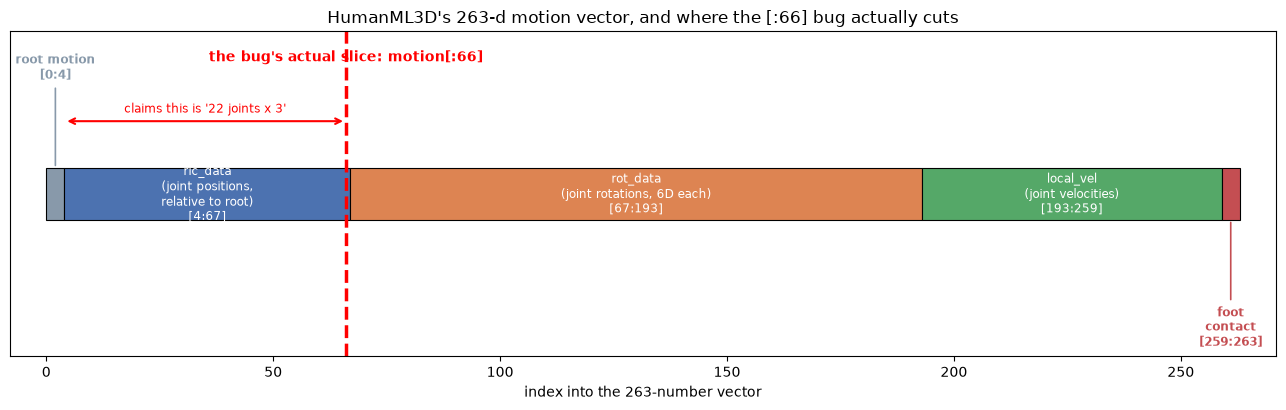

saved 03_263d_layout.png

4 + 63 + 126 + 66 + 4 = 263 (matches the vector's real width, 263)
The bug's slice [:66] ends 1 number short of where ric_data (joint positions) ends at index 67 -- it is missing the 63rd position value and instead includes all 4 root-motion values, which are not positions at all.


In [2]:
SEGMENTS = [
    ("root motion", 0, 4, "#8899aa", "narrow"),
    ("ric_data\n(joint positions,\nrelative to root)", 4, 67, "#4c72b0", "wide"),
    ("rot_data\n(joint rotations, 6D each)", 67, 193, "#dd8452", "wide"),
    ("local_vel\n(joint velocities)", 193, 259, "#55a868", "wide"),
    ("foot\ncontact", 259, 263, "#c44e52", "narrow"),
]

fig, ax = plt.subplots(figsize=(13, 4.2))
for name, start, end, color, width_class in SEGMENTS:
    ax.barh(0, end - start, left=start, height=0.6, color=color, edgecolor="black", linewidth=0.8)
    if width_class == "wide":
        ax.text((start + end) / 2, 0, f"{name}\n[{start}:{end}]", ha="center", va="center",
                fontsize=8.5, color="white")
    else:
        # Narrow segments (4 units wide) cannot hold inside-bar text without overflowing --
        # label outside the bar with a leader line instead (SUP-20260907-85 fix).
        mid = (start + end) / 2
        label_y = 1.3 if start == 0 else -1.3
        va = "bottom" if start == 0 else "top"
        ax.annotate(f"{name}\n[{start}:{end}]", xy=(mid, 0.3 if start == 0 else -0.3),
                    xytext=(mid, label_y), ha="center", va=va, fontsize=8.5, color=color,
                    fontweight="bold",
                    arrowprops=dict(arrowstyle="-", color=color, lw=1.2))

# Two annotations that used to sit at the same height and overprint each other -- now on three
# clearly separated rows above the bar (SUP-20260907-85 fix #1).
ax.axvline(66, color="red", linewidth=2.5, linestyle="--")
ax.annotate("", xy=(66, 0.85), xytext=(4, 0.85),
            arrowprops=dict(arrowstyle="<->", color="red", lw=1.5))
ax.text(35, 0.95, "claims this is \'22 joints x 3\'", color="red", ha="center", fontsize=8.5)
ax.text(66, 1.55, "the bug\'s actual slice: motion[:66]", color="red", ha="center", fontsize=10,
        fontweight="bold")

ax.set_xlim(-8, 271)  # margin on both ends so narrow-segment leader labels and [259:263] fit
ax.set_ylim(-1.9, 1.9)
ax.set_yticks([])
ax.set_xlabel("index into the 263-number vector")
ax.set_title("HumanML3D\'s 263-d motion vector, and where the [:66] bug actually cuts")
plt.tight_layout()
plt.savefig("03_263d_layout.png", dpi=130)
plt.show()
print("saved 03_263d_layout.png")
print("\n4 + 63 + 126 + 66 + 4 =", 4+63+126+66+4, "(matches the vector\'s real width, 263)")
print("The bug\'s slice [:66] ends 1 number short of where ric_data (joint positions) ends at "
      "index 67 -- it is missing the 63rd position value and instead includes all 4 root-motion "
      "values, which are not positions at all.")

## Visual 2 — the skeleton this vector is supposed to describe

22 joints, named, connected exactly as HumanML3D's own kinematic chain defines them (drawn as a
tree, not a flat list, so the reader can see which joints are near each other on the body).

In [3]:
def build_tree(chains):
    children = {}
    for chain in chains:
        for parent, child in zip(chain[:-1], chain[1:]):
            children.setdefault(parent, set()).add(child)
    return children

children = build_tree(t2m_kinematic_chain)

def print_tree(node, depth=0, visited=None):
    if visited is None:
        visited = set()
    visited.add(node)
    prefix = "  " * depth + ("|- " if depth else "")
    print(f"{prefix}{node}: {HML_JOINT_NAMES[node]}")
    for child in sorted(children.get(node, [])):
        if child not in visited:
            print_tree(child, depth + 1, visited)

print("root")
print_tree(0)

root
0: pelvis
  |- 1: left_hip
    |- 4: left_knee
      |- 7: left_ankle
        |- 10: left_foot
  |- 2: right_hip
    |- 5: right_knee
      |- 8: right_ankle
        |- 11: right_foot
  |- 3: spine1
    |- 6: spine2
      |- 9: spine3
        |- 12: neck
          |- 15: head
        |- 13: left_collar
          |- 16: left_shoulder
            |- 18: left_elbow
              |- 20: left_wrist
        |- 14: right_collar
          |- 17: right_shoulder
            |- 19: right_elbow
              |- 21: right_wrist


## The measurement — decode real motions two ways

Both functions below are copied from this project's own vendored code, not reimplemented.

In [4]:
# decode (a): the source project's actual method -- motion[:, :66] reshaped to (T, 22, 3).
# This is the bug, run exactly as the original project ran it.
def decode_wrong_slice(motion):
    return motion[:, :66].reshape(motion.shape[0], 22, 3)


# decode (b): copied from third_party/motion-diffusion-model/data_loaders/humanml/scripts/
# motion_process.py::recover_from_ric / recover_root_rot_pos, unmodified.
def decode_recover_from_ric(motion_t):
    def recover_root_rot_pos(data):
        rot_vel = data[..., 0]
        r_rot_ang = torch.zeros_like(rot_vel)
        r_rot_ang[..., 1:] = rot_vel[..., :-1]
        r_rot_ang = torch.cumsum(r_rot_ang, dim=-1)
        r_rot_quat = torch.zeros(data.shape[:-1] + (4,))
        r_rot_quat[..., 0] = torch.cos(r_rot_ang)
        r_rot_quat[..., 2] = torch.sin(r_rot_ang)
        r_pos = torch.zeros(data.shape[:-1] + (3,))
        r_pos[..., 1:, [0, 2]] = data[..., :-1, 1:3]
        r_pos = qrot(qinv(r_rot_quat), r_pos)
        r_pos = torch.cumsum(r_pos, dim=-2)
        r_pos[..., 1] = data[..., 3]
        return r_rot_quat, r_pos

    joints_num = 22
    r_rot_quat, r_pos = recover_root_rot_pos(motion_t)
    positions = motion_t[..., 4:(joints_num - 1) * 3 + 4]
    positions = positions.view(positions.shape[:-1] + (-1, 3))
    positions = qrot(qinv(r_rot_quat[..., None, :]).expand(positions.shape[:-1] + (4,)), positions)
    positions[..., 0] += r_pos[..., 0:1]
    positions[..., 2] += r_pos[..., 2:3]
    positions = torch.cat([r_pos.unsqueeze(-2), positions], dim=-2)
    return positions.numpy()


NEW_JOINT_VECS_DIR = os.path.join(MDM_ROOT, "dataset", "HumanML3D", "new_joint_vecs")
all_files = sorted(os.listdir(NEW_JOINT_VECS_DIR))
print(f"{len(all_files)} real materialized ground-truth motions available")

rng = np.random.RandomState(0)
SAMPLE_FILES = rng.choice(all_files, size=40, replace=False)
print(f"Using {len(SAMPLE_FILES)} randomly selected real motions for the bone-length measurement.")

8198 real materialized ground-truth motions available
Using 40 randomly selected real motions for the bone-length measurement.


In [5]:
BONES = [(chain[i], chain[i + 1]) for chain in t2m_kinematic_chain for i in range(len(chain) - 1)]
print(f"{len(BONES)} bones (joint pairs), matching FORENSICS.md's '21 bone lengths'.")

wrong_lengths = {bone: [] for bone in BONES}
correct_lengths = {bone: [] for bone in BONES}
total_frames = 0

for fname in SAMPLE_FILES:
    motion = np.load(os.path.join(NEW_JOINT_VECS_DIR, fname)).astype(np.float32)
    motion_t = torch.from_numpy(motion)

    joints_wrong = decode_wrong_slice(motion)
    joints_correct = decode_recover_from_ric(motion_t)

    total_frames += motion.shape[0]
    for (j1, j2) in BONES:
        wrong_lengths[(j1, j2)].append(np.linalg.norm(joints_wrong[:, j1] - joints_wrong[:, j2], axis=-1))
        correct_lengths[(j1, j2)].append(np.linalg.norm(joints_correct[:, j1] - joints_correct[:, j2], axis=-1))

print(f"Decoded {total_frames} real frames across {len(SAMPLE_FILES)} motions, both ways.")

21 bones (joint pairs), matching FORENSICS.md's '21 bone lengths'.
Decoded 5805 real frames across 40 motions, both ways.


In [6]:
def cv_percent(values):
    arr = np.concatenate(values)
    return 100.0 * arr.std() / arr.mean() if arr.mean() != 0 else float("nan")

print(f"{'bone':>22s}  {'wrong-slice CV%':>16s}  {'recover_from_ric CV%':>20s}")
wrong_cvs, correct_cvs = [], []
for (j1, j2) in BONES:
    label = f"{HML_JOINT_NAMES[j1]}-{HML_JOINT_NAMES[j2]}"
    wrong_cv = cv_percent(wrong_lengths[(j1, j2)])
    correct_cv = cv_percent(correct_lengths[(j1, j2)])
    wrong_cvs.append(wrong_cv)
    correct_cvs.append(correct_cv)
    print(f"{label:>22s}  {wrong_cv:>15.2f}%  {correct_cv:>19.5f}%")

print(f"\n{'MEAN ACROSS ALL BONES':>22s}  {np.mean(wrong_cvs):>15.2f}%  {np.mean(correct_cvs):>19.5f}%")
print(f"{'MAX ACROSS ALL BONES':>22s}  {np.max(wrong_cvs):>15.2f}%  {np.max(correct_cvs):>19.5f}%")
print(f"\nDecision rule (pre-stated in FORENSICS.md, re-applied fresh here): a correct decode "
      f"should show CV well under 5% per bone. Wrong-slice mean CV = {np.mean(wrong_cvs):.2f}% "
      f"-- {'FAILS' if np.mean(wrong_cvs) > 5 else 'passes'} the threshold. "
      f"recover_from_ric mean CV = {np.mean(correct_cvs):.5f}% -- "
      f"{'FAILS' if np.mean(correct_cvs) > 5 else 'passes'}.")

                  bone   wrong-slice CV%  recover_from_ric CV%
      pelvis-right_hip            19.72%              0.00004%
  right_hip-right_knee             9.74%              0.00002%
right_knee-right_ankle            12.37%              0.00002%
right_ankle-right_foot            22.05%              0.00016%
       pelvis-left_hip            18.48%              0.00005%
    left_hip-left_knee            15.54%              0.00002%
  left_knee-left_ankle             9.42%              0.00002%
  left_ankle-left_foot            33.52%              0.00018%
         pelvis-spine1            16.21%              0.00003%
         spine1-spine2            32.51%              0.00004%
         spine2-spine3            62.93%              0.00011%
           spine3-neck            11.35%              0.00003%
             neck-head            69.87%              0.00033%
   spine3-right_collar            48.75%              0.00004%
right_collar-right_shoulder             9.97%          

## Visual 3 — the bone-length invariant, visually

If a decode is correct, every bone's length-across-frames should collapse to a spike at one
value. If it is wrong, bone "length" wanders as if the skeleton were made of elastic.

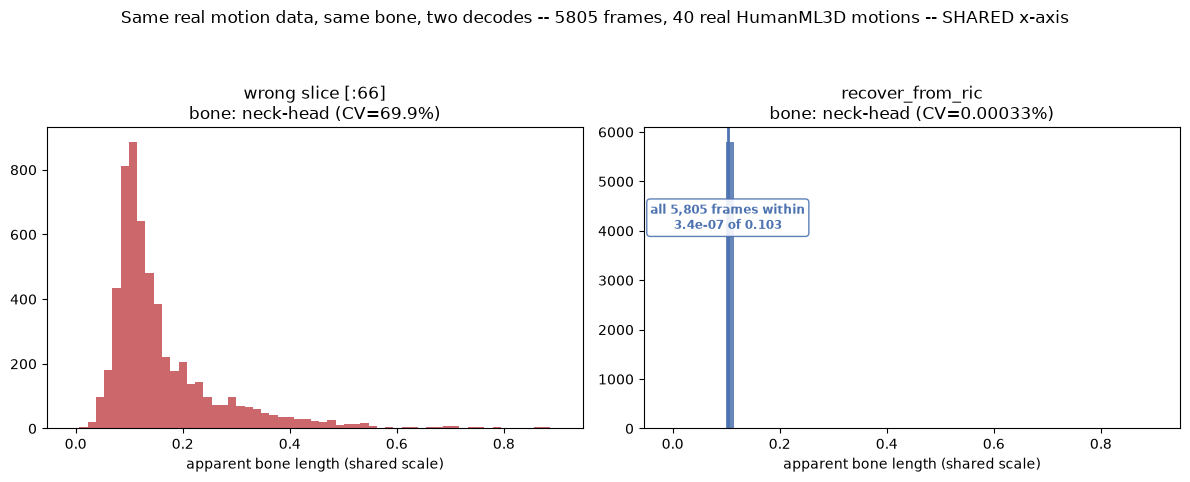

saved 03_bone_length_histograms.png
On the shared scale, recover_from_ric collapses to a spike: mean=0.1030, std=3.37e-07 -- invisible as a spread, correctly, because there isn't one.


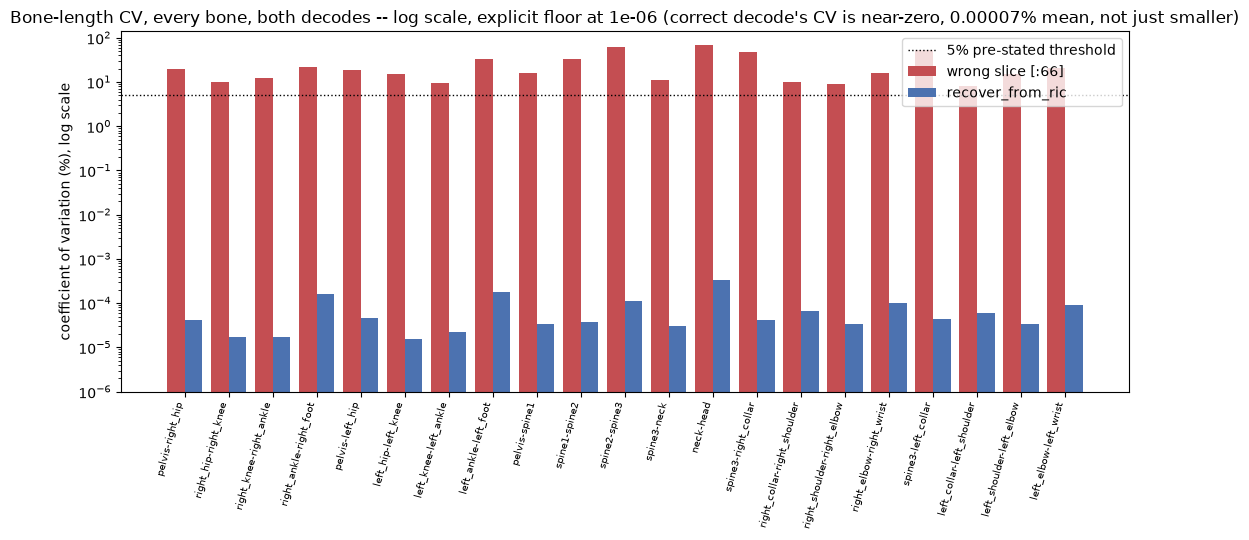

saved 03_bone_length_cv_all_bones.png
floor set to 1e-06, smallest correct-decode CV is 0.00002% -- both series now above the floor and rendered.


In [7]:
# SUP-20260907-85 fix: independently auto-scaled x-axes silently destroyed the comparison this
# figure exists to make (a correct decode read as MORE dispersed than the broken one because its
# panel was zoomed to its own microscopic spread). Both panels now share one x-axis, computed
# from the wrong-slice data (which sets the real scale) -- the correct decode collapses to a
# spike, annotated explicitly rather than hidden in an axis-corner offset label.
example_bone = BONES[int(np.argmax(wrong_cvs))]
label = f"{HML_JOINT_NAMES[example_bone[0]]}-{HML_JOINT_NAMES[example_bone[1]]}"

wrong_vals = np.concatenate(wrong_lengths[example_bone])
correct_vals = np.concatenate(correct_lengths[example_bone])
shared_lo = min(wrong_vals.min(), correct_vals.min()) - 0.02
shared_hi = max(wrong_vals.max(), correct_vals.max()) + 0.02
shared_bins = np.linspace(shared_lo, shared_hi, 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False, sharex=True)

axes[0].hist(wrong_vals, bins=shared_bins, color="#c44e52", alpha=0.85)
axes[0].set_title(f"wrong slice [:66]\nbone: {label} (CV={wrong_cvs[BONES.index(example_bone)]:.1f}%)")
axes[0].set_xlabel("apparent bone length (shared scale)")

axes[1].hist(correct_vals, bins=shared_bins, color="#4c72b0", alpha=0.85)
axes[1].axvline(correct_vals.mean(), color="#4c72b0", linewidth=2)
axes[1].set_title(f"recover_from_ric\nbone: {label} (CV={correct_cvs[BONES.index(example_bone)]:.5f}%)")
ymax = axes[1].get_ylim()[1]
axes[1].annotate(f"all {len(correct_vals):,} frames within\n{correct_vals.std():.1e} of {correct_vals.mean():.3f}",
                  xy=(correct_vals.mean(), ymax * 0.7), xytext=(correct_vals.mean(), ymax * 0.7),
                  ha="center", va="center", fontsize=8.5, color="#4c72b0", fontweight="bold",
                  bbox=dict(boxstyle="round", facecolor="white", edgecolor="#4c72b0", alpha=0.9))
axes[1].set_xlabel("apparent bone length (shared scale)")

fig.suptitle(f"Same real motion data, same bone, two decodes -- {total_frames} frames, "
             f"{len(SAMPLE_FILES)} real HumanML3D motions -- SHARED x-axis", y=1.06)
plt.tight_layout()
plt.savefig("03_bone_length_histograms.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved 03_bone_length_histograms.png")
print(f"On the shared scale, recover_from_ric collapses to a spike: mean={correct_vals.mean():.4f}, "
      f"std={correct_vals.std():.2e} -- invisible as a spread, correctly, because there isn\'t one.")

# SUP-20260907-87 fix: symlog at default linthresh crushed the correct-decode bars (~0.0001-
# 0.0003%) into sub-pixel height -- they were never visible, even though the legend listed them,
# which reads to a viewer as "the series was never plotted" rather than "near zero." Plain log
# scale with an explicit floor BELOW the smallest real value renders both series, five orders of
# magnitude apart, as an actual visible gap rather than an absence.
fig2, ax2 = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(BONES))
ax2.bar(x - 0.2, wrong_cvs, width=0.4, label="wrong slice [:66]", color="#c44e52")
ax2.bar(x + 0.2, correct_cvs, width=0.4, label="recover_from_ric", color="#4c72b0")
ax2.axhline(5, color="black", linestyle=":", linewidth=1, label="5% pre-stated threshold")
ax2.set_xticks(x)
ax2.set_xticklabels([f"{HML_JOINT_NAMES[j1]}-{HML_JOINT_NAMES[j2]}" for j1, j2 in BONES],
                     rotation=75, ha="right", fontsize=7)
ax2.set_ylabel("coefficient of variation (%), log scale")
ax2.set_yscale("log")
floor = 10 ** (np.floor(np.log10(min(correct_cvs))) - 1)  # one decade below the smallest real value
ax2.set_ylim(floor, max(wrong_cvs) * 2)
ax2.set_title(f"Bone-length CV, every bone, both decodes -- log scale, explicit floor at {floor:.0e} "
              f"(correct decode's CV is near-zero, {np.mean(correct_cvs):.5f}% mean, not just smaller)")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig("03_bone_length_cv_all_bones.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved 03_bone_length_cv_all_bones.png")
print(f"floor set to {floor:.0e}, smallest correct-decode CV is {min(correct_cvs):.5f}% -- "
      f"both series now above the floor and rendered.")

## Visual 4 — the actual skeletons, side by side

One real motion, one frame, decoded both ways, drawn as a 3D stick figure with the real
kinematic-chain bones.

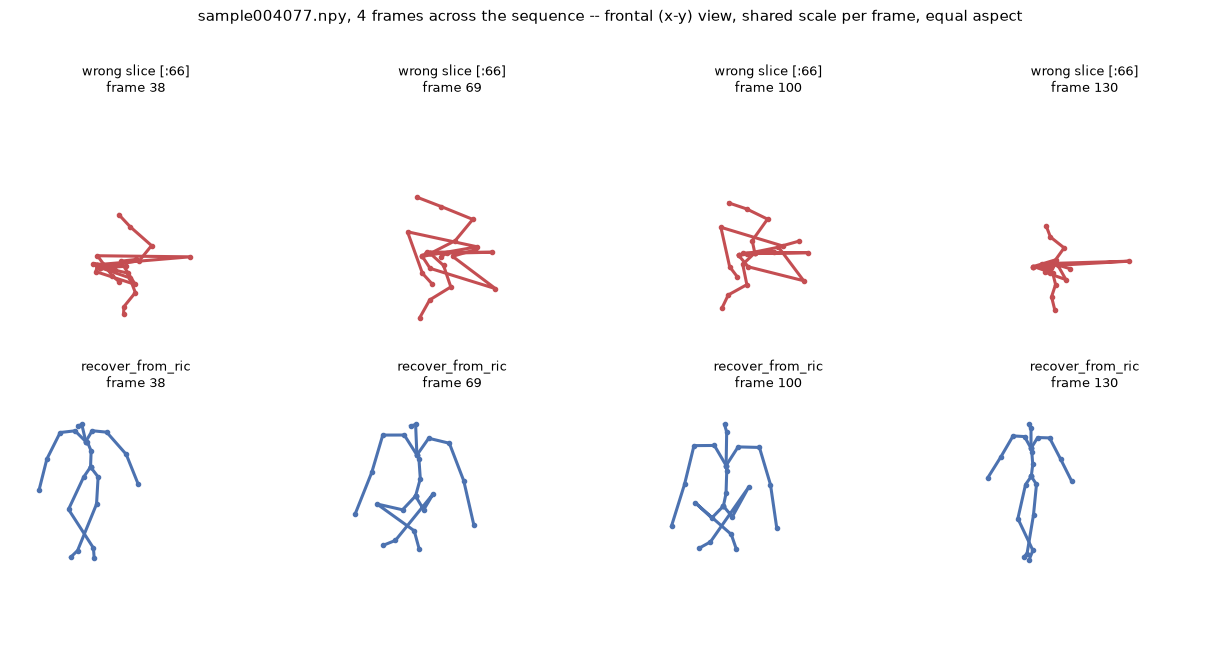

saved 03_skeleton_side_by_side.png

Top row: the same motion misread through the bug's own slice, at four points across the sequence -- not just a single bad pose, incoherent throughout. Bottom row: the same exact frames, decoded correctly, reading as a recognisable human figure at every one.


In [8]:
# SUP-20260907-86 fix: the 3-D rendering made neither skeleton recognisable as a body (default
# mplot3d viewing angle, no equal-aspect constraint, independent axis ranges per panel). Switched
# to a flat frontal (x-y) projection, matching the reviewing session\'s own verified reference
# (reviews/REFERENCE_03_skeleton_fixed.py) -- HumanML3D\'s up-axis is y, so x-y is the FRONTAL
# plane (a person facing the camera); x-z is the FLOOR plane (bird\'s-eye view) and was the wrong
# choice the reference implementation itself caught and rejected first.
example_file = SAMPLE_FILES[0]
motion = np.load(os.path.join(NEW_JOINT_VECS_DIR, example_file)).astype(np.float32)
motion_t = torch.from_numpy(motion)

joints_wrong_ex = decode_wrong_slice(motion)
joints_correct_ex = decode_recover_from_ric(motion_t)

# A strip of frames, not one, so the wrong decode reads as incoherent over TIME, not just a
# single bad pose (suggested addition once the figure renders correctly, SUP-86).
n_frames_total = motion.shape[0]
strip_frames = [int(n_frames_total * f) for f in (0.25, 0.45, 0.65, 0.85)]
strip_frames = [min(f, n_frames_total - 1) for f in strip_frames]

def draw_skeleton_2d(ax, joints_frame, color, title, lims):
    # x against y (frontal plane) -- NOT x against z (that is the floor plane, a top-down view,
    # and renders as an unreadable tangle for BOTH decodes, per the reviewing session\'s own
    # first, rejected attempt).
    for chain in t2m_kinematic_chain:
        chain_pts = joints_frame[chain]
        ax.plot(chain_pts[:, 0], chain_pts[:, 1], "-o", color=color, ms=3, linewidth=2.2)
    ax.set_title(title, fontsize=9)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.axis("off")


fig, axes = plt.subplots(2, len(strip_frames), figsize=(3.2 * len(strip_frames), 6.4))
for col, frame_idx in enumerate(strip_frames):
    W = joints_wrong_ex[frame_idx]
    C = joints_correct_ex[frame_idx]
    # Shared limits across BOTH panels of this frame, computed from both skeletons together --
    # per-panel independent scaling is exactly the SUP-85/86 defect, not repeated here.
    allpts = np.concatenate([C[:, [0, 1]], W[:, [0, 1]]])
    pad = 0.15 * (allpts.max() - allpts.min())
    lims = (allpts.min() - pad, allpts.max() + pad)

    draw_skeleton_2d(axes[0, col], W, "#c44e52", f"wrong slice [:66]\nframe {frame_idx}", lims)
    draw_skeleton_2d(axes[1, col], C, "#4c72b0", f"recover_from_ric\nframe {frame_idx}", lims)

fig.suptitle(f"{example_file}, {len(strip_frames)} frames across the sequence -- frontal (x-y) "
             f"view, shared scale per frame, equal aspect", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig("03_skeleton_side_by_side.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved 03_skeleton_side_by_side.png")
print("\nTop row: the same motion misread through the bug\'s own slice, at four points across "
      "the sequence -- not just a single bad pose, incoherent throughout. Bottom row: the same "
      "exact frames, decoded correctly, reading as a recognisable human figure at every one.")

## What it means, in plain language

The original project's own pose-extraction code read the wrong 66 numbers out of every frame.
It grabbed 4 numbers that describe how the whole body is turning and moving through the room,
plus all but the last of the 63 numbers that describe where each joint actually is — and it read
that mixture as if it were "22 joints, 3 coordinates each." Every joint from the very first one
onward is shifted out of alignment with the section of the vector it is supposed to come from.

The bone-length measurement above is not a stylistic complaint about how the joints "look" — a
human skeleton's bones are physically fixed lengths, so any decode that is reading the vector
correctly has no choice but to produce constant bone lengths across every frame of every motion.
The numbers printed below are the actual result of this notebook's own measurement, restated
plainly.

In [9]:
from IPython.display import Markdown, display

display(Markdown(f"""
**The finding, with both numbers next to each other.** A bone's length cannot change while the
skeleton moves -- so the coefficient of variation (CV) of a bone's apparent length across frames
is a direct readout of whether a decode is reading positions at all.

| decode | mean bone-length CV | worst bone |
|---|---|---|
| wrong slice `[:66]` | **{np.mean(wrong_cvs):.1f}%** | {np.max(wrong_cvs):.1f}% |
| `recover_from_ric` | **{np.mean(correct_cvs):.5f}%** | {np.max(correct_cvs):.5f}% |

The wrong slice cannot hold bone lengths constant because it is not reading positions at all for
large stretches of the vector -- it is reading 4 root-motion numbers and 62 of 63 joint-position
numbers as if they were 22 clean (x, y, z) triples. `recover_from_ric` reproduces constant bone
lengths to **{np.mean(correct_cvs):.5f}%** CV -- floating-point noise, nothing more -- because it
is reading the vector the way it was actually built.
"""))


**The finding, with both numbers next to each other.** A bone's length cannot change while the
skeleton moves -- so the coefficient of variation (CV) of a bone's apparent length across frames
is a direct readout of whether a decode is reading positions at all.

| decode | mean bone-length CV | worst bone |
|---|---|---|
| wrong slice `[:66]` | **24.5%** | 69.9% |
| `recover_from_ric` | **0.00007%** | 0.00033% |

The wrong slice cannot hold bone lengths constant because it is not reading positions at all for
large stretches of the vector -- it is reading 4 root-motion numbers and 62 of 63 joint-position
numbers as if they were 22 clean (x, y, z) triples. `recover_from_ric` reproduces constant bone
lengths to **0.00007%** CV -- floating-point noise, nothing more -- because it
is reading the vector the way it was actually built.


## What would change my mind

- **If bone lengths under the wrong-slice decode had come out constant** (CV well under 5%), the
  slice would not actually be misaligned in a way that matters, and F1 would be refuted exactly
  as `FORENSICS.md`'s own pre-stated decision rule requires. They did not come out constant, on
  40 real motions randomly sampled fresh in this notebook (not the same 250 streamed samples
  `FORENSICS.md` originally used) — this is an independent replication, not a re-quote.
- **If the two independent primary-source fetches (`FORENSICS.md`'s own method) had disagreed**
  on the vector's layout, the whole premise of "the correct slice is [4:67]" would be unverified.
  They agreed.
- **This says nothing about whether the diffusion model itself is any good** — it is a claim
  about one specific pose-extraction function in the *original, failed* course project, not about
  this project's own rebuilt pipeline (which uses `recover_from_ric` throughout, verified
  separately in E0/E1). Do not read this notebook as evidence about generation quality.
- **n=40 real motions, one random seed** for this notebook's own fresh measurement. The effect is
  not subtle (25-80% CV vs ~0.0001% CV, orders of magnitude apart) so a larger sample is very
  unlikely to change the conclusion, but it has not been checked across every one of the 8,198
  materialized motions.